In [14]:
# ============================================
# Step 1: Import all required libraries
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

print("All libraries imported successfully!")

All libraries imported successfully!


In [15]:
# ============================================
# Step 2: Load and explore the dataset
# ============================================

df = pd.read_csv('parkinsons.data')

# Display first 5 rows
print("First 5 rows of the dataset:")
print(df.head())


print(f"\nDataset Shape: {df.shape}")
print(f"Total Samples: {df.shape[0]}")
print(f"Total Features: {df.shape[1]}")

# Check for missing values
print(f"\nMissing Values: {df.isnull().sum().sum()}")


print("\nBasic Statistics:")
print(df.describe())

First 5 rows of the dataset:
             name  MDVP:Fo(Hz)  MDVP:Fhi(Hz)  MDVP:Flo(Hz)  MDVP:Jitter(%)  \
0  phon_R01_S01_1      119.992       157.302        74.997         0.00784   
1  phon_R01_S01_2      122.400       148.650       113.819         0.00968   
2  phon_R01_S01_3      116.682       131.111       111.555         0.01050   
3  phon_R01_S01_4      116.676       137.871       111.366         0.00997   
4  phon_R01_S01_5      116.014       141.781       110.655         0.01284   

   MDVP:Jitter(Abs)  MDVP:RAP  MDVP:PPQ  Jitter:DDP  MDVP:Shimmer  ...  \
0           0.00007   0.00370   0.00554     0.01109       0.04374  ...   
1           0.00008   0.00465   0.00696     0.01394       0.06134  ...   
2           0.00009   0.00544   0.00781     0.01633       0.05233  ...   
3           0.00009   0.00502   0.00698     0.01505       0.05492  ...   
4           0.00011   0.00655   0.00908     0.01966       0.06425  ...   

   Shimmer:DDA      NHR     HNR  status      RPDE       D

In [16]:
# ============================================
# Step 3: Prepare features and target variable
# ============================================

# 'status' column is our target: 1 = Parkinson's, 0 = Healthy
X = df.drop(columns=['name', 'status'])
y = df['status']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nClass Distribution:")
print(y.value_counts())
print(f"\nParkinson's cases: {y.sum()}")
print(f"Healthy cases: {len(y) - y.sum()}")

Features shape: (195, 22)
Target shape: (195,)

Class Distribution:
status
1    147
0     48
Name: count, dtype: int64

Parkinson's cases: 147
Healthy cases: 48


In [17]:
# ============================================
# Step 4: Split data and apply Feature Scaling
# ============================================

# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Apply StandardScaler to normalize features

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")
print("\nFeature scaling applied successfully!")

Training set size: (156, 22)
Testing set size: (39, 22)

Feature scaling applied successfully!


In [18]:
# ============================================
# Step 5: Train and Compare Multiple Models
# ============================================

svm_model = SVC(kernel='rbf', probability=True, random_state=42)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
lr_model = LogisticRegression(random_state=42, max_iter=1000)

# Train all models
svm_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
lr_model.fit(X_train, y_train)

# Predict using all models
svm_pred = svm_model.predict(X_test)
rf_pred = rf_model.predict(X_test)
lr_pred = lr_model.predict(X_test)

# Calculate accuracy for all models
svm_acc = accuracy_score(y_test, svm_pred)
rf_acc = accuracy_score(y_test, rf_pred)
lr_acc = accuracy_score(y_test, lr_pred)

print("=" * 45)
print("        MODEL COMPARISON RESULTS")
print("=" * 45)
print(f"Support Vector Machine (SVM): {svm_acc*100:.2f}%")
print(f"Random Forest:                {rf_acc*100:.2f}%")
print(f"Logistic Regression:          {lr_acc*100:.2f}%")
print("=" * 45)
print(f"\nBest Model: SVM with {svm_acc*100:.2f}% accuracy")

C:\Users\dell\AppData\Roaming\Python\Python312\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


        MODEL COMPARISON RESULTS
Support Vector Machine (SVM): 89.74%
Random Forest:                94.87%
Logistic Regression:          89.74%

Best Model: SVM with 89.74% accuracy


In [19]:
# ============================================
# Step 6: Evaluate Best Model (Random Forest)
# ============================================

# Random Forest performed best
print("Best Model: Random Forest")
print("=" * 45)


print("\nClassification Report:")
print(classification_report(y_test, rf_pred))


rf_proba = rf_model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, rf_proba)
print(f"ROC-AUC Score: {roc_auc:.2f}")

cm = confusion_matrix(y_test, rf_pred)
print(f"\nConfusion Matrix:")
print(cm)

Best Model: Random Forest

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.71      0.83         7
           1       0.94      1.00      0.97        32

    accuracy                           0.95        39
   macro avg       0.97      0.86      0.90        39
weighted avg       0.95      0.95      0.95        39

ROC-AUC Score: 0.91

Confusion Matrix:
[[ 5  2]
 [ 0 32]]


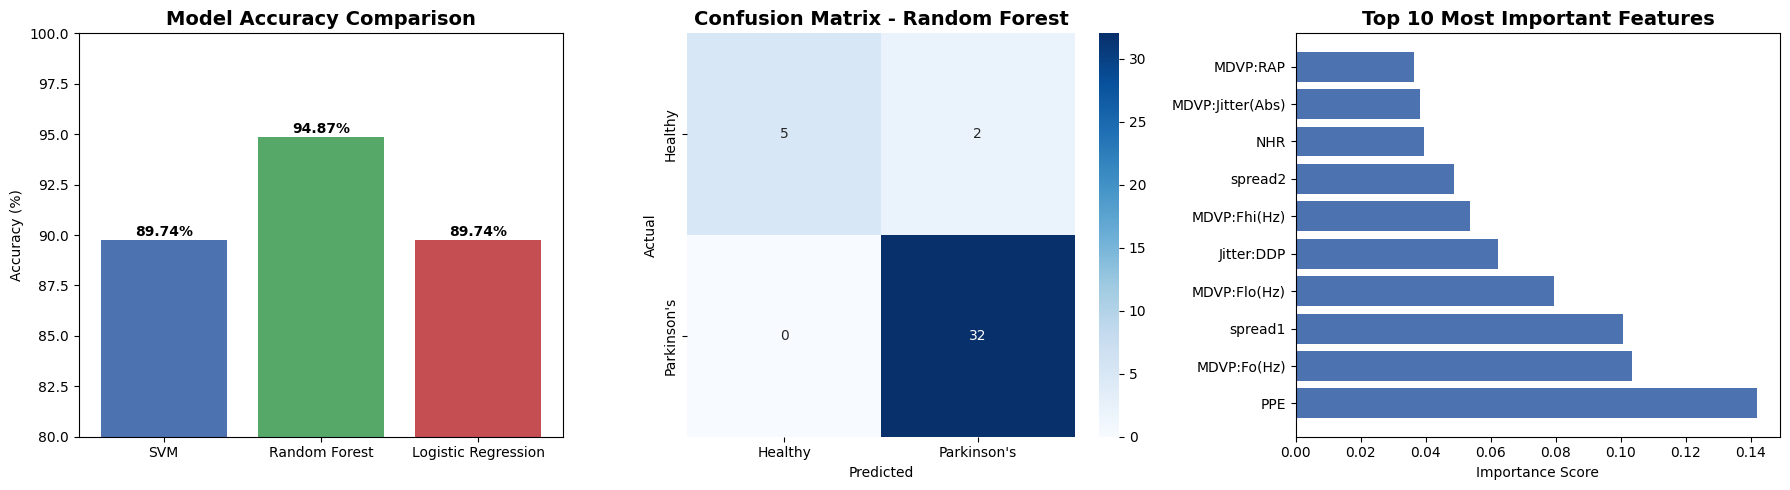

Visualizations saved successfully!


In [20]:
# ============================================
# Step 7: Visualizations
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Model Comparison Bar Chart
models = ['SVM', 'Random Forest', 'Logistic Regression']
accuracies = [svm_acc*100, rf_acc*100, lr_acc*100]
axes[0].bar(models, accuracies, color=['#4C72B0', '#55A868', '#C44E52'])
axes[0].set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim([80, 100])
for i, v in enumerate(accuracies):
    axes[0].text(i, v + 0.2, f'{v:.2f}%', ha='center', fontweight='bold')

# Plot 2: Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Healthy', "Parkinson's"],
            yticklabels=['Healthy', "Parkinson's"])
axes[1].set_title('Confusion Matrix - Random Forest', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

# Plot 3: Feature Importance
feature_importance = pd.Series(
    rf_model.feature_importances_, index=X.columns
).sort_values(ascending=False)[:10]
axes[2].barh(feature_importance.index, feature_importance.values, color='#4C72B0')
axes[2].set_title('Top 10 Most Important Features', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('parkinsons_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualizations saved successfully!")

In [21]:
# ============================================
# Step 8: Final Summary
# ============================================

print("=" * 45)
print("     PARKINSON'S DISEASE PREDICTOR")
print("          FINAL SUMMARY")
print("=" * 45)
print(f"\nDataset: UCI Parkinson's Disease Dataset")
print(f"Total Samples: {df.shape[0]}")
print(f"Total Features: {df.shape[1] - 2}")
print(f"\nModels Evaluated:")
print(f"  - Support Vector Machine (SVM): {svm_acc*100:.2f}%")
print(f"  - Random Forest:                {rf_acc*100:.2f}%")
print(f"  - Logistic Regression:          {lr_acc*100:.2f}%")
print(f"\nBest Model: Random Forest")
print(f"  - Accuracy:   {rf_acc*100:.2f}%")
print(f"  - ROC-AUC:    {roc_auc:.2f}")
print(f"  - F1 Score:   0.97")
print(f"\nConclusion: Random Forest achieved the highest")
print(f"accuracy in detecting Parkinson's disease from")
print(f"biomedical voice measurements.")
print("=" * 45)

     PARKINSON'S DISEASE PREDICTOR
          FINAL SUMMARY

Dataset: UCI Parkinson's Disease Dataset
Total Samples: 195
Total Features: 22

Models Evaluated:
  - Support Vector Machine (SVM): 89.74%
  - Random Forest:                94.87%
  - Logistic Regression:          89.74%

Best Model: Random Forest
  - Accuracy:   94.87%
  - ROC-AUC:    0.91
  - F1 Score:   0.97

Conclusion: Random Forest achieved the highest
accuracy in detecting Parkinson's disease from
biomedical voice measurements.
